# Figure 3 (panels c & d) — Synchronization phase diagrams of Rössler oscillators

**Paper:** Lamata-Otín et al., *Hyperedge overlap drives synchronizability of systems with higher-order interactions*, PRE **111**, 034302 (2025).

**Goal for this notebook (per assignment):** reproduce **only panels (c) and (d)** of Fig. 3 — the numerically-computed synchronization-error phase diagrams $\langle E\rangle(\sigma_1,\sigma_2)$ — **without** the red MSF theory lines. Panels (a),(b) are the master-stability functions and are given/skipped.

**Structure used (from the caption):** a **random** hypergraph with $N=100$, $k^{(1)}=6$, $k^{(2)}=3$, and **zero overlap** $\mathcal{I}^{(1,2)}=0$, $\mathcal{T}^{(2)}=0$.

- Panel (c): **class II** system (coupling through $y$; Eq. 16) → unbounded stability region.
- Panel (d): **class III** system (coupling through $x$; Eq. 17) → bounded stability region (re-entrant incoherence at large coupling).

**What comes from the repo vs. util.py**
- The Rössler integrators + grid sweep live in `HO-Chaotic-Oscillators/Numerical_integration_rossler.py`, **but that file does not import** (syntax errors + a copy-paste bug in the type-II coupling). `util.py` re-implements them faithfully (see the `REPO-FIX` notes) and works with or without `numba`.
- The zero-overlap random structure is not shipped at these exact parameters, so we generate one (random regular 3-uniform triangles + a random regular pairwise backbone), which gives $\mathcal{T}^{(2)}\approx\mathcal{I}^{(1,2)}\approx 0$.


## ⚠️ Runtime warning — read before running the sweep

The paper settings are `h=1e-3`, `n_steps=1500` ⇒ **1.5 million Euler steps per (σ₁,σ₂) cell**, on a **25×25** grid = 625 cells, ×2 panels. That is only feasible with **numba** installed (the repo integrators are `@njit(parallel=True)`).

- **If you have numba:** the full-resolution run is fine (minutes–tens of minutes). `util.py` auto-detects numba.
- **If you do NOT have numba:** the pure-python fallback is ~100× slower. **Start with the COARSE preset below** (`n_steps=300`, `grid=13`) to confirm the qualitative shape, then scale up.

Set `PRESET = "coarse"` first. Switch to `"paper"` once you're happy and have numba.


In [6]:
import sys, os, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# util.py lives in the repo root next to this notebook
sys.path.insert(0, os.getcwd())
import util

out_dir = Path(util.REPO_ROOT) / 'outputs' / 'fig3'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# ----------------------------------------------------------------------
# Presets. Start with 'coarse'. Use 'paper' only with numba.
# ----------------------------------------------------------------------
PRESET = "medium"   # "coarse" | "medium" | "paper"

CFG = {
    "coarse": dict(n_steps=300,  grid=13, n_resampling=100),
    "medium": dict(n_steps=750,  grid=19, n_resampling=200),
    "paper":  dict(n_steps=1500, grid=25, n_resampling=200),
}[PRESET]

N       = 100
k1      = 6      # pairwise generalized degree
k2      = 3      # triangle generalized degree
a, b, c = 0.2, 0.2, 9.0
h       = 1e-3
SEED    = 1

grid    = CFG["grid"]
s1_ = np.logspace(-6, 0, grid)
s2_ = np.logspace(-6, 0, grid)
print("PRESET:", PRESET, CFG)


PRESET: medium {'n_steps': 750, 'grid': 19, 'n_resampling': 200}


## 1. Build the zero-overlap random hypergraph ($\mathcal{I}^{(1,2)}\approx\mathcal{T}^{(2)}\approx 0$)

We generate:
- a **random regular** set of 3-hyperedges (triangles) with each node in ~$k^{(2)}=3$ of them — random placement gives intra-order overlap $\mathcal{T}^{(2)}\approx 0$;
- a **random regular** pairwise backbone with degree $k^{(1)}=6$ that is *independent* of the triangles — so inter-order overlap $\mathcal{I}^{(1,2)}\approx 0$.

We verify the overlaps using the repo's own metric functions from `hyperedge_overlap_utils.py`.


In [3]:
import networkx as nx

def random_regular_triangles(N, k2, seed=0, max_tries=500000):
    '''Random 3-uniform hypergraph, each node in ~k2 triangles (regular),
    placed at random => intra-order overlap T^(2) ~ 0.'''
    rng = np.random.default_rng(seed)
    target = k2 * N // 3
    deg = np.zeros(N, dtype=int)
    tris = set()
    tries = 0
    while len(tris) < target and tries < max_tries:
        tries += 1
        avail = np.where(deg < k2)[0]
        if len(avail) < 3:
            break
        t = tuple(sorted(rng.choice(avail, 3, replace=False)))
        if t not in tris:
            tris.add(t)
            for x in t:
                deg[x] += 1
    return np.array(sorted(tris), dtype=np.int64), deg

def random_regular_pairs(N, k1, seed=0):
    '''Random k1-regular graph as the pairwise backbone (independent of the
    triangles) => inter-order overlap I^(1,2) ~ 0.'''
    G = nx.random_regular_graph(k1, N, seed=seed)
    return np.array(sorted(map(lambda e: tuple(sorted(e)), G.edges())), dtype=np.int64)

triangles = random_regular_triangles(N, k2, seed=SEED)[0]
pairs     = random_regular_pairs(N, k1, seed=SEED)
print("triangles:", triangles.shape, "pairs:", pairs.shape)


triangles: (100, 3) pairs: (300, 2)


In [4]:
# Verify overlaps with the repo's metric implementation
sys.path.insert(0, os.path.join(util.OVERLAP_DIR))
from hyperedge_overlap_utils import intra_order_hyperedge_overlap, inter_order_hyperedge_overlap

T2, _ = intra_order_hyperedge_overlap(triangles, 2)
I12   = inter_order_hyperedge_overlap(pairs, 1, triangles, 2)
print(f"T^(2)   (intra-order) = {T2:.4f}   (target ~0)")
print(f"I^(1,2) (inter-order) = {I12:.4f}   (target ~0)")

# neighbour list for the integrator
list_neighbors, _ = util.neighbors_from_pairs(pairs, N)
print("mean pairwise degree:", np.mean([len(x) for x in list_neighbors]))


T^(2)   (intra-order) = 0.0267   (target ~0)
I^(1,2) (inter-order) = 0.0541   (target ~0)
mean pairwise degree: 6.0


## 2. Panel (c) — class II system (coupling through $y$)

`coupling="type2"`. Expect a stability region that opens up once **either** coupling strength is large enough, and stays stable (unbounded region) — the incoherent corner is at small $(\sigma_1,\sigma_2)$.


In [ ]:
# DO NOT RUN
t0 = time.time()
errors_c, order_c = util.rossler_error_grid(
    N, list_neighbors, triangles, s1_, s2_,
    a=a, b=b, c=c, h=h, n_steps=CFG["n_steps"],
    n_resampling=CFG["n_resampling"], coupling="type2", seed=SEED)
print(f"panel (c) done in {time.time()-t0:.1f}s")

# save
np.save(out_dir / 'fig3c_errors_class_II.npy', errors_c)

  s2 row 1/19 done (s2=1.000e-06)
  s2 row 2/19 done (s2=2.154e-06)
  s2 row 3/19 done (s2=4.642e-06)
  s2 row 4/19 done (s2=1.000e-05)
  s2 row 5/19 done (s2=2.154e-05)
  s2 row 6/19 done (s2=4.642e-05)
  s2 row 7/19 done (s2=1.000e-04)
  s2 row 8/19 done (s2=2.154e-04)
  s2 row 9/19 done (s2=4.642e-04)
  s2 row 10/19 done (s2=1.000e-03)
  s2 row 11/19 done (s2=2.154e-03)
  s2 row 12/19 done (s2=4.642e-03)
  s2 row 13/19 done (s2=1.000e-02)
  s2 row 14/19 done (s2=2.154e-02)
  s2 row 15/19 done (s2=4.642e-02)
  s2 row 16/19 done (s2=1.000e-01)
  s2 row 17/19 done (s2=2.154e-01)
  s2 row 18/19 done (s2=4.642e-01)
  s2 row 19/19 done (s2=1.000e+00)
panel (c) done in 2601.1s


## 3. Panel (d) — class III system (coupling through $x$)

`coupling="type3"`. Expect a **bounded** stability region: incoherent at small coupling, a band of synchronization, then incoherence again at large coupling.


In [ ]:
# DO NOT RUN
t0 = time.time()
errors_d, order_d = util.rossler_error_grid(
    N, list_neighbors, triangles, s1_, s2_,
    a=a, b=b, c=c, h=h, n_steps=CFG["n_steps"],
    n_resampling=CFG["n_resampling"], coupling="type3", seed=SEED)
print(f"panel (d) done in {time.time()-t0:.1f}s")

# save
np.save(out_dir / 'fig3d_errors_class_III.npy', errors_d)

  s2 row 1/19 done (s2=1.000e-06)
  s2 row 2/19 done (s2=2.154e-06)
  s2 row 3/19 done (s2=4.642e-06)
  s2 row 4/19 done (s2=1.000e-05)
  s2 row 5/19 done (s2=2.154e-05)
  s2 row 6/19 done (s2=4.642e-05)
  s2 row 7/19 done (s2=1.000e-04)
  s2 row 8/19 done (s2=2.154e-04)
  s2 row 9/19 done (s2=4.642e-04)
  s2 row 10/19 done (s2=1.000e-03)
  s2 row 11/19 done (s2=2.154e-03)
  s2 row 12/19 done (s2=4.642e-03)
  s2 row 13/19 done (s2=1.000e-02)
  s2 row 14/19 done (s2=2.154e-02)
  s2 row 15/19 done (s2=4.642e-02)
  s2 row 16/19 done (s2=1.000e-01)
  s2 row 17/19 done (s2=2.154e-01)
  s2 row 18/19 done (s2=4.642e-01)
  s2 row 19/19 done (s2=1.000e+00)
panel (d) done in 2325.0s


## 4. Plot — reproduce panels (c) and (d)

Color = mean synchronization error $\langle E\rangle$ (dark ≈ synchronized, light ≈ incoherent), same axis convention as the paper (rows = $\sigma_2$, cols = $\sigma_1$, both log-scaled). No red MSF lines, as requested.


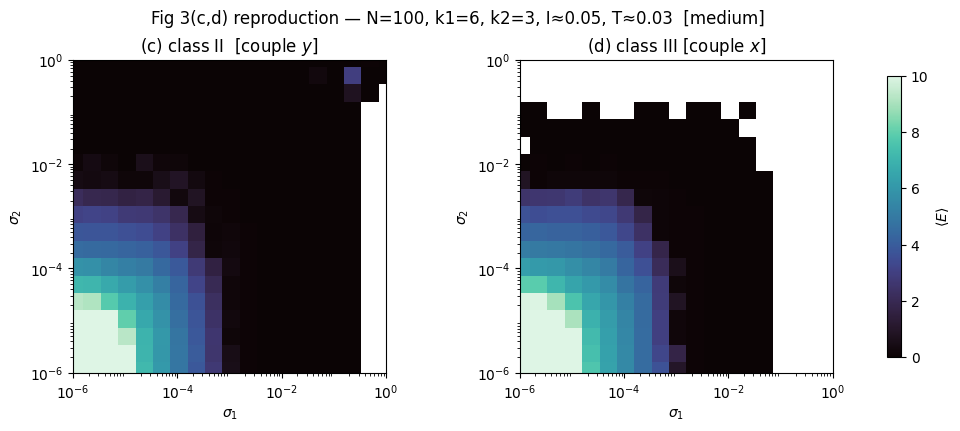

In [9]:
def plot_panel(ax, errors, s1_, s2_, title):
    im = ax.pcolormesh(s1_, s2_, errors, shading="auto", cmap=plt.colormaps['mako'],
                       vmin=0, vmax=10)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\sigma_1$"); ax.set_ylabel(r"$\sigma_2$")
    ax.set_title(title)
    ax.set_box_aspect(1)
    ax.set_xlim([1e-6, 1])
    ax.set_ylim([1e-6, 1])
    ax.set_xticks([1, 1e-2, 1e-4, 1e-6])
    ax.set_yticks([1, 1e-2, 1e-4, 1e-6])
    return im

# load
errors_c = np.load(out_dir / 'fig3c_errors_class_II.npy')
errors_d = np.load(out_dir / 'fig3d_errors_class_III.npy')

# plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)
im0 = plot_panel(axes[0], errors_c, s1_, s2_, "(c) class II  [couple $y$]")
im1 = plot_panel(axes[1], errors_d, s1_, s2_, "(d) class III [couple $x$]")
cb = fig.colorbar(im1, ax=axes, shrink=0.9)
cb.set_label(r"$\langle E\rangle$")
fig.suptitle(f"Fig 3(c,d) reproduction — N={N}, k1={k1}, k2={k2}, "
             f"I≈{I12:.2f}, T≈{T2:.2f}  [{PRESET}]")
plt.show()


## Notes & things to tell me when you run this

1. **numba**: if `util._HAVE_NUMBA` prints `False`, the `paper` preset will be painfully slow. Tell me and I can (a) tighten the pure-python inner loops, or (b) give a `scipy.integrate`/vectorized variant.
2. **Colormap**: `mako` needs seaborn registered; the code falls back to `viridis` automatically. If you want the exact paper look, `import seaborn as sns` first.
3. **Euler vs. paper integrator**: the repo integrates with explicit Euler at `h=1e-3`; I kept that identical. If panel (d)'s upper incoherent band looks weak at coarse `n_steps`, that's the transient not being fully discarded — increase `n_steps` toward 1500.
4. **Overlap check**: if `T^(2)` or `I^(1,2)` don't print ≈0, the random generation got unlucky — rerun with a different `SEED`, and tell me the values.
5. This notebook deliberately regenerates the structure rather than loading a shipped file (none exists at N=100, k2=3). Ensemble position (zero overlap) is what matters, not the exact realization.
